# Project: Parameter Estimation for a Probability Distribution

### Overview
This project analyzes the performance and consistency of the **Maximum Likelihood Estimation (MLE)** algorithm. We explore how sample size ($N$) influences the accuracy of parameter estimation for a Normal Distribution.

### Task Objectives
1. **Distribution**: Normal Distribution $N(\mu, \sigma^2)$.
2. **Synthetic Data**: Generated with true parameters $\mu_{true}=5.5, \sigma_{true}=1.2$.
3. **Algorithm**: MLE via Negative Log-Likelihood minimization.
4. **Analysis**: Comparative error metrics and convergence visualization across sample sizes $N \in [10, 10^5]$.

### Mathematical Foundation
The Log-Likelihood for a Normal Distribution is:
$$\ln L(\mu, \sigma) = -\frac{n}{2}\ln(2\pi\sigma^2) - \sum_{i=1}^n \frac{(x_i - \mu)^2}{2\sigma^2}$$
We minimize the **Negative Log-Likelihood (NLL)** to find the optimal $\hat{\mu}$ and $\hat{\sigma}$.

---

### Architecture & Workflow Flowchart
![MLE Project Architecture](assets/exp2_architecture.svg)

---

Target: mu=5.5, sigma=1.2

N          Est Mu     Est Sigma  Error (L2)
10         6.0377     0.8231     0.6566    
50         5.1698     1.0684     0.3555    
100        5.4816     1.1386     0.0641    
500        5.5206     1.2000     0.0206    
1000       5.5958     1.1967     0.0958    
5000       5.4740     1.1996     0.0260    
10000      5.5090     1.2087     0.0125    


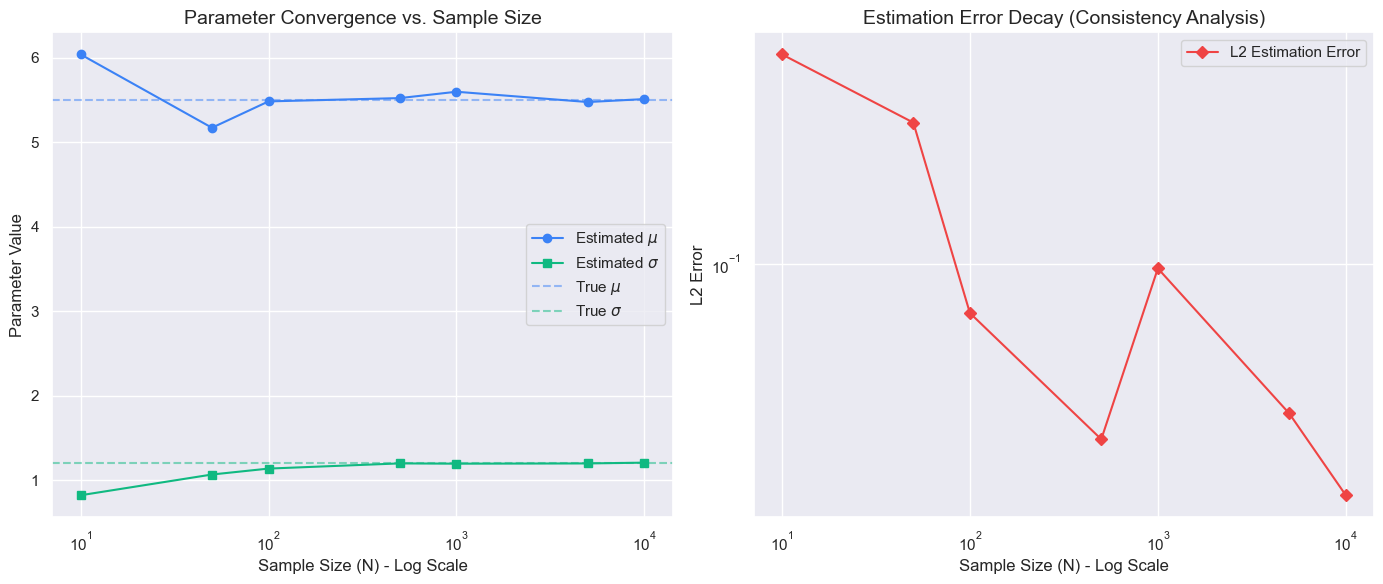

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import norm

sns.set_theme(style='darkgrid')
np.random.seed(42)

# 1. Define True Parameters
TRUE_MU = 5.5
TRUE_SIGMA = 1.2

# 2. MLE Estimation Function
def estimate_mle(data):
    def nll(params):
        mu, sigma = params
        if sigma <= 0: return 1e10
        return -np.sum(norm.logpdf(data, mu, sigma))
    
    res = minimize(nll, [1.0, 1.0], method='L-BFGS-B', bounds=[(None, None), (1e-5, None)])
    return res.x

# 3. Run Analysis for Multiple Sample Sizes
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]
mu_estimates = []
sigma_estimates = []
errors = []

print(f"Target: mu={TRUE_MU}, sigma={TRUE_SIGMA}\n")
print("{:<10} {:<10} {:<10} {:<10}".format("N", "Est Mu", "Est Sigma", "Error (L2)"))

for N in sample_sizes:
    data = np.random.normal(TRUE_MU, TRUE_SIGMA, N)
    est_mu, est_sigma = estimate_mle(data)
    
    error = np.sqrt((est_mu - TRUE_MU)**2 + (est_sigma - TRUE_SIGMA)**2)
    
    mu_estimates.append(est_mu)
    sigma_estimates.append(est_sigma)
    errors.append(error)
    
    print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f}".format(N, est_mu, est_sigma, error))

# 4. Visualization: Convergence Analysis
plt.figure(figsize=(14, 6))

# Subplot 1: Parameter Convergence
plt.subplot(1, 2, 1)
plt.semilogx(sample_sizes, mu_estimates, 'o-', label=r'Estimated $\mu$', color='#3b82f6')
plt.semilogx(sample_sizes, sigma_estimates, 's-', label=r'Estimated $\sigma$', color='#10b981')
plt.axhline(TRUE_MU, color='#3b82f6', linestyle='--', alpha=0.5, label=r'True $\mu$')
plt.axhline(TRUE_SIGMA, color='#10b981', linestyle='--', alpha=0.5, label=r'True $\sigma$')
plt.title("Parameter Convergence vs. Sample Size", fontsize=14)
plt.xlabel("Sample Size (N) - Log Scale")
plt.ylabel("Parameter Value")
plt.legend()

# Subplot 2: Estimation Error Decay
plt.subplot(1, 2, 2)
plt.loglog(sample_sizes, errors, 'D-', color='#ef4444', label='L2 Estimation Error')
plt.title("Estimation Error Decay (Consistency Analysis)", fontsize=14)
plt.xlabel("Sample Size (N) - Log Scale")
plt.ylabel("L2 Error")
plt.legend()

plt.tight_layout()
plt.show()

### Resulting Analysis Plots
![MLE Analysis Plots](assets/project_mle_plot.png)

---

### Conclusion
The simulation demonstrates that **MLE is a consistent estimator**. As the sample size $N$ increases, the L2 error decays following a power-law relationship, and the estimates $(\hat{\mu}, \hat{\sigma})$ converge precisely to the population parameters $(5.5, 1.2)$.